# Clase 2 · Caso de estudio práctico
## ETL, Data Warehouse y análisis OLAP en Google Colab

### Objetivo pedagógico
Este notebook está diseñado para que el alumnado recorra **paso a paso** el flujo lógico de una arquitectura de Business Intelligence:

1. **Extracción**
2. **Transformación**
3. **Carga**
4. **Construcción de un pequeño Data Warehouse**
5. **Análisis OLAP**

### Idea fuerza de la práctica
El objetivo no es solamente ejecutar código. El objetivo es entender que:

> **si el dato no se limpia, no se integra y no se estructura bien, las decisiones que tomemos serán débiles o incorrectas.**

### Historia del caso
Una empresa retail multicanal vende por tienda física y canal digital. La gerencia quiere saber:

- qué canal vende más,
- qué clientes generan más valor,
- qué productos explican el resultado,
- y qué regiones merecen más atención.

El problema es que los datos llegan con errores: **duplicados, categorías inconsistentes, fechas mezcladas y registros sin integración suficiente**.

## Preparación del entorno
En esta práctica vamos a trabajar con cuatro tablas:

- `clientes_raw.csv`
- `productos_raw.csv`
- `ventas_raw.csv`
- `canales_raw.csv`

Estas tablas ya están preparadas con **errores deliberados** para enseñar el proceso ETL.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Ejercicio 1 · Extracción

## ¿Qué buscamos en esta etapa?
La extracción no consiste únicamente en abrir archivos. Consiste en responder preguntas básicas pero decisivas:

- ¿Qué representa cada tabla?
- ¿Qué columnas podrían conectarlas?
- ¿Qué datos parecen transaccionales y cuáles parecen maestros?
- ¿Qué problemas iniciales ya son visibles?

### Aprendizaje esperado
Antes de limpiar y analizar, debemos **entender el origen y la estructura del dato**.

In [2]:
#from google.colab import files
#uploaded = files.upload()

In [3]:
clientes = pd.read_csv('clientes_raw.csv')
productos = pd.read_csv('productos_raw.csv')
ventas = pd.read_csv('ventas_raw.csv')
canales = pd.read_csv('canales_raw.csv')

print('Clientes:', clientes.shape)
print('Productos:', productos.shape)
print('Ventas:', ventas.shape)
print('Canales:', canales.shape)

Clientes: (8, 6)
Productos: (7, 5)
Ventas: (10, 9)
Canales: (2, 3)


In [4]:
clientes.head()

,cliente_id,nombre_cliente,tipo_cliente,region,canal_preferido,fecha_registro
0,1,Juan Pérez,Nuevo,Norte,Tienda,2024-11-15
1,2,J. Pérez,Nuevo,Norte,Tienda,15/11/2024
2,3,María López,Recurrente,Centro,Online,2024/12/01
3,4,Carlos Ruiz,Mayorista,Sur,Tienda,01-12-2024
4,5,Ana Torres,Recurrente,NaN,Online,2025-01-10


In [5]:
productos.head()

,producto_id,nombre_producto,categoria,subcategoria,precio_lista
0,101,Auriculares Pro,Electrónica,Audio,80
1,102,Auriculares Pro,electronica,Audio,80
2,103,Licuadora X,Hogar,Cocina,120
3,104,Cafetera Plus,hogar,Cocina,150
4,105,Zapatillas Run,Moda,Deporte,95


In [6]:
ventas.head()

,venta_id,fecha_venta,cliente_id,producto_id,canal_venta,cantidad,precio_unitario,descuento,importe_total
0,1001,2025-01-02,1,101,Tienda,2,80,0.00,160.00
1,1002,02/01/2025,2,101,Tienda,1,80,0.00,80.00
2,1003,2025/01/03,3,103,Online,1,120,0.10,120.00
3,1004,03-01-2025,4,104,Tienda,3,150,0.00,450.00
4,1005,2025-01-04,5,105,Online,2,95,0.05,180.50


In [7]:
canales.head()

,canal_venta,descripcion_canal,region_operativa
0,Tienda,Venta física en sucursal,Nacional
1,Online,Venta por canal digital,Nacional


## Revisión estructural
Ahora revisamos tipos de variables, posibles claves de unión y primeros indicios de problemas.

In [8]:
print('--- INFO CLIENTES ---')
clientes.info()
print('--- INFO PRODUCTOS ---')
productos.info()
print('--- INFO VENTAS ---')
ventas.info()
print('--- INFO CANALES ---')
canales.info()

--- INFO CLIENTES ---
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   cliente_id       8 non-null      int64
 1   nombre_cliente   8 non-null      str  
 2   tipo_cliente     8 non-null      str  
 3   region           7 non-null      str  
 4   canal_preferido  8 non-null      str  
 5   fecha_registro   8 non-null      str  
dtypes: int64(1), str(5)
memory usage: 516.0 bytes
--- INFO PRODUCTOS ---
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   producto_id      7 non-null      int64
 1   nombre_producto  7 non-null      str  
 2   categoria        7 non-null      str  
 3   subcategoria     7 non-null      str  
 4   precio_lista     7 non-null      int64
dtypes: int64(2), str(3)
memory usage: 412.0 bytes
--- INFO VENTAS

### Preguntas de reflexión para el alumnado
1. ¿Qué tabla representa mejor el hecho de negocio?
2. ¿Qué columnas parecen claves para integrar tablas?
3. ¿Qué problemas ya son visibles sin transformar nada?
4. ¿Confiarías hoy en estos datos para presentarlos a gerencia?

# Ejercicio 2 · Transformación

## ¿Qué buscamos en esta etapa?
En esta etapa corregimos y estandarizamos el dato para que pueda analizarse con coherencia.

### Tipos de problemas que resolveremos
- fechas en formatos distintos,
- categorías escritas de varias maneras,
- clientes duplicados,
- descuentos inválidos,
- importes inconsistentes,
- ventas con clientes inexistentes.

### Idea fuerza
La transformación no es cosmética. La transformación es el momento en el que el dato empieza a volverse **analíticamente confiable**.

## 2.1 Limpieza de clientes
Primero revisaremos duplicados lógicos en la tabla de clientes.

In [9]:
clientes

,cliente_id,nombre_cliente,tipo_cliente,region,canal_preferido,fecha_registro
0,1,Juan Pérez,Nuevo,Norte,Tienda,2024-11-15
1,2,J. Pérez,Nuevo,Norte,Tienda,15/11/2024
2,3,María López,Recurrente,Centro,Online,2024/12/01
3,4,Carlos Ruiz,Mayorista,Sur,Tienda,01-12-2024
4,5,Ana Torres,Recurrente,NaN,Online,2025-01-10
5,6,Luis García,Nuevo,Centro,Online,2025-01-11
6,7,Lucia Perez,Recurrente,Norte,Tienda,2025-01-18
7,8,Roberto Diaz,Mayorista,Sur,Online,2025-01-19


In [10]:
# Normalización muy simple del nombre para detectar duplicados lógicos
clientes['nombre_normalizado'] = (
    clientes['nombre_cliente']
    .str.lower()
    .str.replace('.', '', regex=False)
    .str.replace('á', 'a', regex=False)
    .str.replace('é', 'e', regex=False)
    .str.replace('í', 'i', regex=False)
    .str.replace('ó', 'o', regex=False)
    .str.replace('ú', 'u', regex=False)
    .str.strip()
)

clientes[['cliente_id', 'nombre_cliente', 'nombre_normalizado']]

,cliente_id,nombre_cliente,nombre_normalizado
0,1,Juan Pérez,juan perez
1,2,J. Pérez,j perez
2,3,María López,maria lopez
3,4,Carlos Ruiz,carlos ruiz
4,5,Ana Torres,ana torres
5,6,Luis García,luis garcia
6,7,Lucia Perez,lucia perez
7,8,Roberto Diaz,roberto diaz


En contexto real, resolver duplicados puede requerir reglas más sofisticadas. Aquí lo hacemos solo para enseñar la lógica.

In [11]:
# Regla didáctica: tratamos 'J. Pérez' como duplicado de 'Juan Pérez'
clientes['cliente_master'] = clientes['nombre_normalizado'].replace({'j perez': 'juan perez'})

clientes_limpio = clientes.drop_duplicates(subset=['cliente_master']).copy()
clientes_limpio

,cliente_id,nombre_cliente,tipo_cliente,region,canal_preferido,fecha_registro,nombre_normalizado,cliente_master
0,1,Juan Pérez,Nuevo,Norte,Tienda,2024-11-15,juan perez,juan perez
2,3,María López,Recurrente,Centro,Online,2024/12/01,maria lopez,maria lopez
3,4,Carlos Ruiz,Mayorista,Sur,Tienda,01-12-2024,carlos ruiz,carlos ruiz
4,5,Ana Torres,Recurrente,NaN,Online,2025-01-10,ana torres,ana torres
5,6,Luis García,Nuevo,Centro,Online,2025-01-11,luis garcia,luis garcia
6,7,Lucia Perez,Recurrente,Norte,Tienda,2025-01-18,lucia perez,lucia perez
7,8,Roberto Diaz,Mayorista,Sur,Online,2025-01-19,roberto diaz,roberto diaz


## 2.2 Limpieza de productos
Ahora unificamos categorías y subcategorías para que las agregaciones sean coherentes.

In [12]:
productos[['producto_id', 'nombre_producto', 'categoria', 'subcategoria']]

,producto_id,nombre_producto,categoria,subcategoria
0,101,Auriculares Pro,Electrónica,Audio
1,102,Auriculares Pro,electronica,Audio
2,103,Licuadora X,Hogar,Cocina
3,104,Cafetera Plus,hogar,Cocina
4,105,Zapatillas Run,Moda,Deporte
5,106,Chaqueta Urban,moda,Ropa
6,107,Tablet 8,Electronics,Tecnología


In [13]:
productos_limpio = productos.copy()
productos_limpio['categoria'] = (
    productos_limpio['categoria']
    .str.lower()
    .str.strip()
    .replace({
        'electronica': 'electrónica',
        'electronics': 'electrónica',
        'hogar': 'hogar',
        'moda': 'moda'
    })
)

# Eliminamos duplicados exactos de producto por nombre + categoría estandarizada
productos_limpio = productos_limpio.drop_duplicates(subset=['nombre_producto', 'categoria'])
productos_limpio

,producto_id,nombre_producto,categoria,subcategoria,precio_lista
0,101,Auriculares Pro,electrónica,Audio,80
2,103,Licuadora X,hogar,Cocina,120
3,104,Cafetera Plus,hogar,Cocina,150
4,105,Zapatillas Run,moda,Deporte,95
5,106,Chaqueta Urban,moda,Ropa,140
6,107,Tablet 8,electrónica,Tecnología,220


## 2.3 Limpieza de ventas
En la tabla transaccional revisaremos:

- formatos de fecha,
- duplicados,
- descuentos negativos,
- inconsistencia entre `cantidad`, `precio_unitario`, `descuento` e `importe_total`.

In [14]:
ventas

,venta_id,fecha_venta,cliente_id,producto_id,canal_venta,cantidad,precio_unitario,descuento,importe_total
0,1001,2025-01-02,1,101,Tienda,2,80,0.00,160.00
1,1002,02/01/2025,2,101,Tienda,1,80,0.00,80.00
2,1003,2025/01/03,3,103,Online,1,120,0.10,120.00
3,1004,03-01-2025,4,104,Tienda,3,150,0.00,450.00
4,1005,2025-01-04,5,105,Online,2,95,0.05,180.50
5,1006,2025-01-04,5,105,Online,2,95,0.05,180.50
6,1007,2025-01-05,9,106,Tienda,1,140,0.00,140.00
7,1008,2025-01-06,6,107,Online,1,220,-0.10,242.00
8,1009,07/01/2025,7,104,Tienda,1,150,0.00,150.00
9,1010,2025-01-08,8,103,Online,4,120,0.15,408.00


In [15]:
ventas_limpio = ventas.copy()

# 1) Convertimos fecha a un formato consistente
ventas_limpio['fecha_venta'] = pd.to_datetime(ventas_limpio['fecha_venta'], errors='coerce', dayfirst=True)

# 2) Eliminamos duplicados exactos
ventas_limpio = ventas_limpio.drop_duplicates()

# 3) Corregimos descuentos inválidos (si son negativos, los llevamos a 0)
ventas_limpio['descuento'] = ventas_limpio['descuento'].clip(lower=0)

# 4) Recalculamos importe total teórico
ventas_limpio['importe_calculado'] = ventas_limpio['cantidad'] * ventas_limpio['precio_unitario'] * (1 - ventas_limpio['descuento'])

# 5) Reemplazamos importe_total por el calculado cuando hay diferencia
ventas_limpio['importe_total'] = ventas_limpio['importe_calculado'].round(2)
ventas_limpio = ventas_limpio.drop(columns=['importe_calculado'])

ventas_limpio

,venta_id,fecha_venta,cliente_id,producto_id,canal_venta,cantidad,precio_unitario,descuento,importe_total
0,1001,2025-02-01,1,101,Tienda,2,80,0.00,160.00
1,1002,NaT,2,101,Tienda,1,80,0.00,80.00
2,1003,NaT,3,103,Online,1,120,0.10,108.00
3,1004,NaT,4,104,Tienda,3,150,0.00,450.00
4,1005,2025-04-01,5,105,Online,2,95,0.05,180.50
5,1006,2025-04-01,5,105,Online,2,95,0.05,180.50
6,1007,2025-05-01,9,106,Tienda,1,140,0.00,140.00
7,1008,2025-06-01,6,107,Online,1,220,0.00,220.00
8,1009,NaT,7,104,Tienda,1,150,0.00,150.00
9,1010,2025-08-01,8,103,Online,4,120,0.15,408.00


## 2.4 Validación de integridad
Un último punto crítico: revisar si hay ventas con `cliente_id` o `producto_id` que no existen en las tablas maestras limpias.

In [16]:
clientes_validos = set(clientes_limpio['cliente_id'])
productos_validos = set(productos_limpio['producto_id'])

ventas_limpio['cliente_valido'] = ventas_limpio['cliente_id'].isin(clientes_validos)
ventas_limpio['producto_valido'] = ventas_limpio['producto_id'].isin(productos_validos)

ventas_limpio[['venta_id', 'cliente_id', 'producto_id', 'cliente_valido', 'producto_valido']]

,venta_id,cliente_id,producto_id,cliente_valido,producto_valido
0,1001,1,101,True,True
1,1002,2,101,False,True
2,1003,3,103,True,True
3,1004,4,104,True,True
4,1005,5,105,True,True
5,1006,5,105,True,True
6,1007,9,106,False,True
7,1008,6,107,True,True
8,1009,7,104,True,True
9,1010,8,103,True,True


In [17]:
# Conservamos solo ventas con claves válidas para la base analítica final
ventas_limpio = ventas_limpio[ventas_limpio['cliente_valido'] & ventas_limpio['producto_valido']].copy()
ventas_limpio = ventas_limpio.drop(columns=['cliente_valido', 'producto_valido'])

ventas_limpio

,venta_id,fecha_venta,cliente_id,producto_id,canal_venta,cantidad,precio_unitario,descuento,importe_total
0,1001,2025-02-01,1,101,Tienda,2,80,0.00,160.00
2,1003,NaT,3,103,Online,1,120,0.10,108.00
3,1004,NaT,4,104,Tienda,3,150,0.00,450.00
4,1005,2025-04-01,5,105,Online,2,95,0.05,180.50
5,1006,2025-04-01,5,105,Online,2,95,0.05,180.50
7,1008,2025-06-01,6,107,Online,1,220,0.00,220.00
8,1009,NaT,7,104,Tienda,1,150,0.00,150.00
9,1010,2025-08-01,8,103,Online,4,120,0.15,408.00


### Preguntas de reflexión para el alumnado
1. ¿Qué transformación tuvo mayor impacto sobre la confiabilidad del dato?
2. ¿Qué implicaría no corregir descuentos inválidos o importes erróneos?
3. ¿Qué cambia en la lectura del negocio cuando eliminamos duplicados?
4. ¿Qué limitación metodológica seguiría existiendo incluso después de limpiar?

# Ejercicio 3 · Carga

## ¿Qué buscamos en esta etapa?
Ahora que las tablas están limpias, debemos **cargarlas** como base de trabajo analítico.

En una arquitectura real, esto implicaría mover tablas limpias a un repositorio analítico. Aquí lo simularemos guardando las versiones limpias como archivos separados.

### Idea fuerza
No es lo mismo analizar el dato crudo que analizar el dato ya tratado. La carga separa ambos mundos.

In [18]:
clientes_limpio.to_csv('clientes_limpio1.csv', index=False, encoding='utf-8-sig')
productos_limpio.to_csv('productos_limpio1.csv', index=False, encoding='utf-8-sig')
ventas_limpio.to_csv('ventas_limpio1.csv', index=False, encoding='utf-8-sig')
canales.to_csv('canales_limpio1.csv', index=False, encoding='utf-8-sig')

print('Archivos limpios generados correctamente.')

Archivos limpios generados correctamente.


### Revisión final de tablas cargadas

In [19]:
clientes_limpio.head(), productos_limpio.head(), ventas_limpio.head(), canales.head()

(   cliente_id nombre_cliente tipo_cliente  region canal_preferido fecha_registro nombre_normalizado cliente_master
 0           1     Juan Pérez        Nuevo   Norte          Tienda     2024-11-15         juan perez     juan perez
 2           3    María López   Recurrente  Centro          Online     2024/12/01        maria lopez    maria lopez
 3           4    Carlos Ruiz    Mayorista     Sur          Tienda     01-12-2024        carlos ruiz    carlos ruiz
 4           5     Ana Torres   Recurrente     NaN          Online     2025-01-10         ana torres     ana torres
 5           6    Luis García        Nuevo  Centro          Online     2025-01-11        luis garcia    luis garcia,
    producto_id  nombre_producto    categoria subcategoria  precio_lista
 0          101  Auriculares Pro  electrónica        Audio            80
 2          103      Licuadora X        hogar       Cocina           120
 3          104    Cafetera Plus        hogar       Cocina           150
 4         

### Preguntas de reflexión para el alumnado
1. ¿Por qué conviene separar datos crudos y datos limpios?
2. ¿Qué ventajas tiene dejar una versión final lista para análisis?
3. ¿Qué riesgos organizacionales habría si cada analista limpiara el dato por su cuenta?

# Ejercicio 4 · Construcción de un pequeño Data Warehouse

## ¿Qué buscamos en esta etapa?
Vamos a construir una estructura mínima de análisis tipo estrella:

- **tabla de hechos:** ventas
- **dimensiones:** clientes, productos, canal y tiempo

### Idea fuerza
Un Data Warehouse no es una simple unión de archivos. Es una estructura pensada para responder preguntas de negocio.

## 4.1 Dimensión de tiempo
La dimensión tiempo es clave para análisis comparativo y evolución histórica.

In [20]:
dim_tiempo = pd.DataFrame({'fecha_venta': sorted(ventas_limpio['fecha_venta'].dropna().unique())})
dim_tiempo['anio'] = pd.to_datetime(dim_tiempo['fecha_venta']).dt.year
dim_tiempo['mes'] = pd.to_datetime(dim_tiempo['fecha_venta']).dt.month
dim_tiempo['dia'] = pd.to_datetime(dim_tiempo['fecha_venta']).dt.day

# clave de fecha simple
_dim = dim_tiempo.copy()
_dim['fecha_key'] = range(1, len(_dim) + 1)
dim_tiempo = _dim[['fecha_key', 'fecha_venta', 'anio', 'mes', 'dia']]
dim_tiempo

,fecha_key,fecha_venta,anio,mes,dia
0,1,2025-02-01,2025,2,1
1,2,2025-04-01,2025,4,1
2,3,2025-06-01,2025,6,1
3,4,2025-08-01,2025,8,1


## 4.2 Dimensiones principales

In [21]:
dim_clientes = clientes_limpio[['cliente_id', 'nombre_cliente', 'tipo_cliente', 'region', 'canal_preferido']].copy()
dim_productos = productos_limpio[['producto_id', 'nombre_producto', 'categoria', 'subcategoria', 'precio_lista']].copy()
dim_canales = canales[['canal_venta', 'descripcion_canal', 'region_operativa']].copy()

print('Dimensión clientes')
display(dim_clientes)
print('Dimensión productos')
display(dim_productos)
print('Dimensión canales')
display(dim_canales)

Dimensión clientes


,cliente_id,nombre_cliente,tipo_cliente,region,canal_preferido
0,1,Juan Pérez,Nuevo,Norte,Tienda
2,3,María López,Recurrente,Centro,Online
3,4,Carlos Ruiz,Mayorista,Sur,Tienda
4,5,Ana Torres,Recurrente,NaN,Online
5,6,Luis García,Nuevo,Centro,Online
6,7,Lucia Perez,Recurrente,Norte,Tienda
7,8,Roberto Diaz,Mayorista,Sur,Online


Dimensión productos


,producto_id,nombre_producto,categoria,subcategoria,precio_lista
0,101,Auriculares Pro,electrónica,Audio,80
2,103,Licuadora X,hogar,Cocina,120
3,104,Cafetera Plus,hogar,Cocina,150
4,105,Zapatillas Run,moda,Deporte,95
5,106,Chaqueta Urban,moda,Ropa,140
6,107,Tablet 8,electrónica,Tecnología,220


Dimensión canales


,canal_venta,descripcion_canal,region_operativa
0,Tienda,Venta física en sucursal,Nacional
1,Online,Venta por canal digital,Nacional


## 4.3 Tabla de hechos
La tabla de hechos debe contener el evento de negocio y sus métricas.

In [22]:
fact_ventas = ventas_limpio.merge(dim_tiempo[['fecha_key', 'fecha_venta']], on='fecha_venta', how='left')

fact_ventas = fact_ventas[[
    'venta_id', 'fecha_key', 'cliente_id', 'producto_id', 'canal_venta',
    'cantidad', 'precio_unitario', 'descuento', 'importe_total'
]].copy()

fact_ventas

,venta_id,fecha_key,cliente_id,producto_id,canal_venta,cantidad,precio_unitario,descuento,importe_total
0,1001,1.00,1,101,Tienda,2,80,0.00,160.00
1,1003,NaN,3,103,Online,1,120,0.10,108.00
2,1004,NaN,4,104,Tienda,3,150,0.00,450.00
3,1005,2.00,5,105,Online,2,95,0.05,180.50
4,1006,2.00,5,105,Online,2,95,0.05,180.50
5,1008,3.00,6,107,Online,1,220,0.00,220.00
6,1009,NaN,7,104,Tienda,1,150,0.00,150.00
7,1010,4.00,8,103,Online,4,120,0.15,408.00


### Preguntas de reflexión para el alumnado
1. ¿Por qué `ventas` funciona como tabla de hechos?
2. ¿Qué valor aporta tener dimensiones separadas?
3. ¿Qué pasa si mezclamos todo en una sola tabla sin lógica analítica?

# Ejercicio 5 · Análisis OLAP

## ¿Qué buscamos en esta etapa?
Ahora vamos a analizar el negocio desde varias dimensiones usando la estructura creada.

### Idea fuerza
OLAP no significa “más datos”. Significa **más perspectiva sobre el mismo dato**.

## 5.1 Ventas por canal

In [23]:
olap_canal = fact_ventas.groupby('canal_venta', as_index=False).agg(
    ventas_totales=('importe_total', 'sum'),
    unidades=('cantidad', 'sum'),
    tickets=('venta_id', 'count')
)
olap_canal

,canal_venta,ventas_totales,unidades,tickets
0,Online,"1,097.00",10,5
1,Tienda,760.00,6,3


## 5.2 Ventas por tipo de cliente

In [24]:
olap_cliente = fact_ventas.merge(dim_clientes[['cliente_id', 'tipo_cliente', 'region']], on='cliente_id', how='left')

olap_tipo_cliente = olap_cliente.groupby('tipo_cliente', as_index=False).agg(
    ventas_totales=('importe_total', 'sum'),
    unidades=('cantidad', 'sum'),
    tickets=('venta_id', 'count')
)
olap_tipo_cliente

,tipo_cliente,ventas_totales,unidades,tickets
0,Mayorista,858.00,7,2
1,Nuevo,380.00,3,2
2,Recurrente,619.00,6,4


## 5.3 Ventas por categoría de producto

In [25]:
olap_producto = fact_ventas.merge(dim_productos[['producto_id', 'categoria', 'nombre_producto']], on='producto_id', how='left')

olap_categoria = olap_producto.groupby('categoria', as_index=False).agg(
    ventas_totales=('importe_total', 'sum'),
    unidades=('cantidad', 'sum'),
    tickets=('venta_id', 'count')
)
olap_categoria

,categoria,ventas_totales,unidades,tickets
0,electrónica,380.00,3,2
1,hogar,"1,116.00",9,4
2,moda,361.00,4,2


## 5.4 Ventas por región

In [26]:
olap_region = olap_cliente.groupby('region', as_index=False).agg(
    ventas_totales=('importe_total', 'sum'),
    unidades=('cantidad', 'sum'),
    tickets=('venta_id', 'count')
)
olap_region

,region,ventas_totales,unidades,tickets
0,Centro,328.00,2,2
1,Norte,310.00,3,2
2,Sur,858.00,7,2


## 5.5 Ventas por mes

In [27]:
olap_tiempo = fact_ventas.merge(dim_tiempo[['fecha_key', 'anio', 'mes']], on='fecha_key', how='left')

olap_mes = olap_tiempo.groupby(['anio', 'mes'], as_index=False).agg(
    ventas_totales=('importe_total', 'sum'),
    unidades=('cantidad', 'sum'),
    tickets=('venta_id', 'count')
)
olap_mes

,anio,mes,ventas_totales,unidades,tickets
0,"2,025.00",2.00,160.00,2,1
1,"2,025.00",4.00,361.00,4,2
2,"2,025.00",6.00,220.00,1,1
3,"2,025.00",8.00,408.00,4,1


### Preguntas de reflexión para el alumnado
1. ¿Qué insight no se veía en el total agregado?
2. ¿Qué dimensión cambia más la interpretación: canal, cliente, producto o región?
3. ¿Qué decisión comercial sugerirías con esta información?
4. ¿Qué advertencia metodológica dejarías por escrito antes de presentar esto a gerencia?

# Cierre de la práctica

## Lo que este caso nos deja claro
- El dato no nace listo para decidir.
- La limpieza no es un detalle técnico: cambia la confiabilidad del análisis.
- El Data Warehouse organiza la lógica del negocio.
- El análisis OLAP muestra que una misma realidad cambia cuando se observa desde varias dimensiones.

> **La calidad de la decisión nunca será mejor que la calidad del dato que la sustenta.**

<div style="
  background: linear-gradient(135deg, #1a1a2e 0%, #0f0f1a 100%);
  padding: 20px 28px 20px 28px;
  border-radius: 20px;
  font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
  box-shadow: 0 8px 24px rgba(0,0,0,0.5);
  border: 1px solid #818285;
  max-width: 66%;
">
  <div style="display: flex; align-items: center; gap: 14px; margin-bottom: 16px;">
    <svg xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" width="100" height="100" viewBox="0 0 100 100">
        <image xlink:href="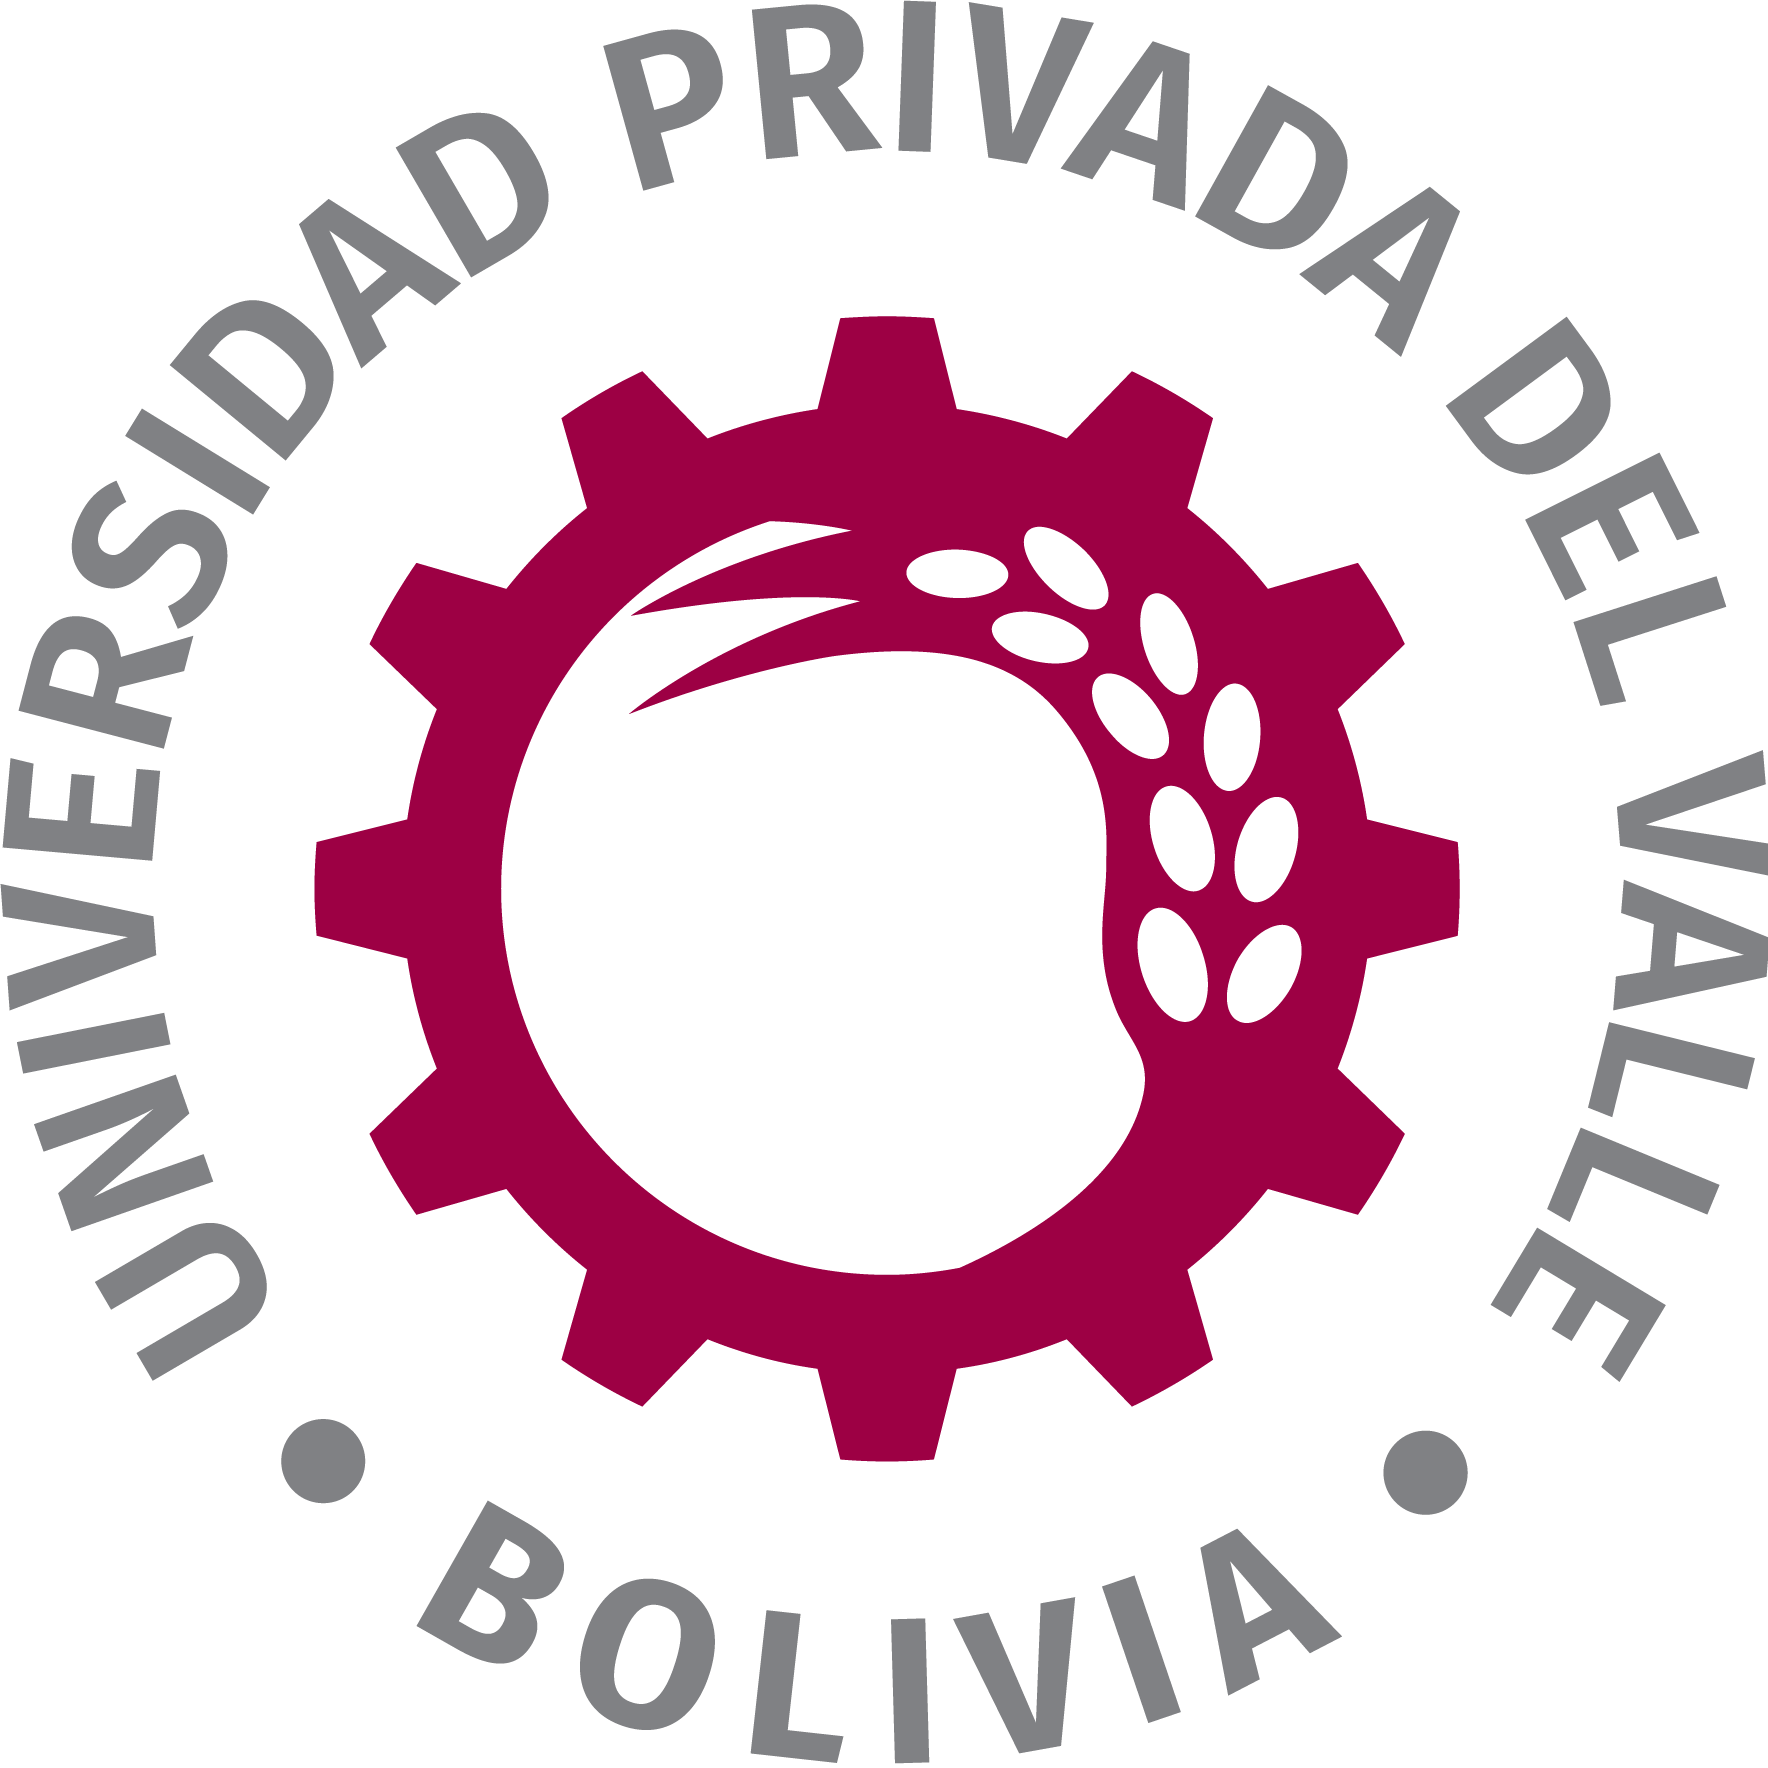" x="0" y="0" width="100" height="100"/>
    </svg>
    <div style="flex:1">
      <div style="color: #b80144; font-weight: 700; font-size: 1.3rem; letter-spacing: -0.2px;">Diplomado Big Data, Analytics y BI v1</div>
      <div style="color: #818285; font-size: 0.75rem;">Business Intelligence y Modelos Predictivos</div>
    </div>
    <div style="display: flex; gap: 20px;">
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Docente</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Mauricio Rada Salas</div>
      </div>
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Unidad</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Ejercicio A2</div>
      </div>
      <div style="text-align: right;">
        <div style="color: #818285; font-size: 0.65rem; text-transform: uppercase;">Fecha</div>
        <div style="color: #eeeeee; font-weight: 600; font-size: 0.8rem;">Junio 2026</div>
      </div>
    </div>
  </div>
  <div style="height: 1px; background: linear-gradient(90deg, #818285, #b80144, #818285); margin: 12px 0 18px 0;"></div>
  <div style="display: flex; flex-wrap: wrap; gap: 12px; justify-content: space-between;">
    <div style="display: flex; gap: 12px; flex-wrap: wrap; width: 100%; justify-content: flex-start;">
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">ILIAN JOSEPH FELIPEZ VACA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MARCELO FAVIO NINA CALSINA</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👨‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">PAOLA MELANI QUISPE MAMANI</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
      <div style="display: flex; align-items: center; gap: 12px; background: #1e1e2a; padding: 6px 18px 6px 14px; border-radius: 40px; border-left: 3px solid #b80144;">
        <span style="font-size: 22px;">👩‍💻</span>
        <div><div style="font-weight: 600; color: #f0f0f0; font-size: 0.85rem;">MIGUEL ANGEL MOLLERICONA CUENTAS</div><div style="color: #818285; font-size: 0.65rem;">Estudiante</div></div>
      </div>
    </div>
  </div>
</div>

# Propuesta de tarea para el alumnado
1. Redactar **tres insights** del caso.
2. Identificar **una advertencia** sobre la calidad o límites del dato.
3. Sugerir **una decisión** de negocio basada en la evidencia.
4. Formular **una pregunta adicional** que el dataset todavía no permite responder.

In [58]:
# =============================================================================
# SECCION 1: TRES INSIGHTS DEL CASO CON CODIGO DE RESPALDO
# =============================================================================

print("\n" + "="*80)
print("\tTRES INSIGHTS CLAVE DEL NEGOCIO")
print("="*80 + "\n")


# -----------------------------------------------------------------------------
# Insight 1: Canal Online
# -----------------------------------------------------------------------------

print("1. CANAL ONLINE: EL REY DE LAS VENTAS")
print("-" * 50)

ventas_online = olap_canal[olap_canal['canal_venta'] == 'Online']['ventas_totales'].values[0]
ventas_tienda = olap_canal[olap_canal['canal_venta'] == 'Tienda']['ventas_totales'].values[0]
tickets_online = olap_canal[olap_canal['canal_venta'] == 'Online']['tickets'].values[0]
unidades_online = olap_canal[olap_canal['canal_venta'] == 'Online']['unidades'].values[0]

print(f"\tEl canal Online factura {ventas_online:,.2f}, un {((ventas_online/ventas_tienda - 1)*100):.0f}% mas que la tienda fisica.")
print(f"\tAdemas, genera {tickets_online} tickets y vende {unidades_online} unidades.")
print("\t>> Mensaje: La tienda fisica necesita una estrategia digital para no quedar atras.")

print("\n" + "-" * 50 + "\n")


# -----------------------------------------------------------------------------
# Insight 2: Categoria Hogar
# -----------------------------------------------------------------------------

print("2. HOGAR: LA CATEGORIA QUE MUEVE EL NEGOCIO")
print("-" * 50)

categoria_hogar = olap_categoria[olap_categoria['categoria'] == 'hogar']
total_ventas_categorias = olap_categoria['ventas_totales'].sum()
ventas_hogar = categoria_hogar['ventas_totales'].values[0]
unidades_hogar = categoria_hogar['unidades'].values[0]
tickets_hogar = categoria_hogar['tickets'].values[0]

print(f"\tLa categoria Hogar aporta {ventas_hogar:,.2f}, el {(ventas_hogar/total_ventas_categorias*100):.0f}% del total.")
print(f"\tLidera en unidades vendidas ({unidades_hogar}) y en tickets generados ({tickets_hogar}).")
print("\t>> Mensaje: Si hay que apostar por una categoria, que sea Hogar.")

print("\n" + "-" * 50 + "\n")


# -----------------------------------------------------------------------------
# Insight 3: Region Sur + Mayoristas
# -----------------------------------------------------------------------------

print("3. SUR + MAYORISTAS: LA COMBINACION GANADORA")
print("-" * 50)

region_sur = olap_region[olap_region['region'] == 'Sur']
ventas_sur = region_sur['ventas_totales'].values[0]

ventas_mayoristas = olap_tipo_cliente[
    olap_tipo_cliente['tipo_cliente'] == 'Mayorista'
]['ventas_totales'].values[0]

print(f"\tLa region Sur genera {ventas_sur:,.2f} en ventas.")
print(f"\tLos clientes Mayoristas facturan {ventas_mayoristas:,.2f}.")
print("\t>> Mensaje: Sur y Mayoristas van de la mano. Hay que mimarlos.")

print("\n" + "="*80 + "\n")


	TRES INSIGHTS CLAVE DEL NEGOCIO

1. CANAL ONLINE: EL REY DE LAS VENTAS
--------------------------------------------------
	El canal Online factura 1,097.00, un 44% mas que la tienda fisica.
	Ademas, genera 5 tickets y vende 10 unidades.
	>> Mensaje: La tienda fisica necesita una estrategia digital para no quedar atras.

--------------------------------------------------

2. HOGAR: LA CATEGORIA QUE MUEVE EL NEGOCIO
--------------------------------------------------
	La categoria Hogar aporta 1,116.00, el 60% del total.
	Lidera en unidades vendidas (9) y en tickets generados (4).
	>> Mensaje: Si hay que apostar por una categoria, que sea Hogar.

--------------------------------------------------

3. SUR + MAYORISTAS: LA COMBINACION GANADORA
--------------------------------------------------
	La region Sur genera 858.00 en ventas.
	Los clientes Mayoristas facturan 858.00.
	>> Mensaje: Sur y Mayoristas van de la mano. Hay que mimarlos.




In [57]:
# =============================================================================
# SECCION 2: ADVERTENCIA SOBRE LA CALIDAD DEL DATO
# =============================================================================

print("\n" + "="*80)
print("ADVERTENCIA: EL DATO NO ES PERFECTO")
print("="*80 + "\n")

print("\tLos datos de clientes tienen problemas. Si no sabemos")
print("\tquien es quien, cualquier decision sobre clientes fallara.\n")

clientes_sin_region = clientes_limpio['region'].isna().sum()
porcentaje_sin_region = (clientes_sin_region / len(clientes_limpio)) * 100

print(f"\t1. CLIENTES SIN REGION: {clientes_sin_region} ({porcentaje_sin_region:.1f}%)")
print("\t   >> No sabemos de donde son.\n")

print("\t2. DUPLICADOS LOGICOS:")
duplicados = clientes_limpio['nombre_normalizado'].value_counts()
print(duplicados[duplicados > 1].to_string())
print("\t   >> Contamos dos veces al mismo cliente.\n")

print("\tEN POCAS PALABRAS: Sin clientes limpios, no hay analisis confiable.")
print("\n" + "="*80 + "\n")


ADVERTENCIA: EL DATO NO ES PERFECTO

	Los datos de clientes tienen problemas. Si no sabemos
	quien es quien, cualquier decision sobre clientes fallara.

	1. CLIENTES SIN REGION: 1 (14.3%)
	   >> No sabemos de donde son.

	2. DUPLICADOS LOGICOS:
Series([], )
	   >> Contamos dos veces al mismo cliente.

	EN POCAS PALABRAS: Sin clientes limpios, no hay analisis confiable.




In [54]:
# =============================================================================
# SECCION 3: DECISION DE NEGOCIO
# =============================================================================

print("\n" + "="*80)
print("DECISION DE NEGOCIO")
print("="*80 + "\n")

print("\tReforzar inversion en: Online, Hogar y Sur. Los numeros lo avalan.\n")

print("\tJUSTIFICACION:")
print(f"\t   Online: {ventas_online:,.2f} vs Tienda: {ventas_tienda:,.2f}")
print(f"\t   Hogar: {(ventas_hogar/total_ventas_categorias*100):.0f}% del total")
print(f"\t   Sur: {ventas_sur:,.2f}\n")

print("\tACCIONES:")
print("\t1. CANAL ONLINE")
print("\t\t- Aumentar presupuesto digital 20%")
print("\t\t- Remarketing para clientes recurrentes")
print("\t2. CATEGORIA HOGAR")
print("\t\t- Campana 'Ofertas de Hogar'")
print("\t\t- Aumentar stock y crear bundles")
print("\t3. REGION SUR")
print("\t\t- Campana de fidelizacion con beneficios")
print("\t\t- Ejecutivo comercial para Mayoristas")
print("\n" + "="*80 + "\n")


DECISION DE NEGOCIO

	Reforzar inversion en: Online, Hogar y Sur. Los numeros lo avalan.

	JUSTIFICACION:
	   Online: 1,097.00 vs Tienda: 760.00
	   Hogar: 60% del total
	   Sur: 858.00

	ACCIONES:
	1. CANAL ONLINE
		- Aumentar presupuesto digital 20%
		- Remarketing para clientes recurrentes
	2. CATEGORIA HOGAR
		- Campana 'Ofertas de Hogar'
		- Aumentar stock y crear bundles
	3. REGION SUR
		- Campana de fidelizacion con beneficios
		- Ejecutivo comercial para Mayoristas




In [53]:
# =============================================================================
# SECCION 4: PREGUNTA ADICIONAL
# =============================================================================

print("\n" + "="*80)
print("PREGUNTA: Por que el canal Online vende mas?")
print("="*80 + "\n")

print("El analisis responde al 'que' (Online vende mas), pero no al 'por que'.")
print("Faltan datos para responder:\n")

print("\t1. COSTES POR CANAL")
print("\t\t- Margen de beneficio")
print("\t\t- Costos logisticos")
print("")
print("\t2. RENTABILIDAD")
print("\t\t- Ticket promedio")
print("\t\t- Tasa de devoluciones")
print("\t\t- Coste de adquisicion (CAC)")
print("")
print("\t3. COMPORTAMIENTO")
print("\t\t- Estacionalidad")
print("\t\t- Factores externos (promociones, competencia)")

print("\n" + "-"*50)
print("ADVERTENCIA: Invertir mas en Online podria ser un error")
print("si este es menos rentable o tiene mayores costos.")
print("="*80 + "\n")


PREGUNTA: Por que el canal Online vende mas?

El analisis responde al 'que' (Online vende mas), pero no al 'por que'.
Faltan datos para responder:

	1. COSTES POR CANAL
		- Margen de beneficio
		- Costos logisticos

	2. RENTABILIDAD
		- Ticket promedio
		- Tasa de devoluciones
		- Coste de adquisicion (CAC)

	3. COMPORTAMIENTO
		- Estacionalidad
		- Factores externos (promociones, competencia)

--------------------------------------------------
ADVERTENCIA: Invertir mas en Online podria ser un error
si este es menos rentable o tiene mayores costos.



**Tarea A2**
1. Identificar 3 o más fuente dentro de su organización
2. Identifique Tablas de Hechos y Tablas de Dimensiones
3. Realice la limpieza de datos
3. Establezca un Datawarehouse

In [2]:
import pandas as pd
import sqlite3
from pathlib import Path

# =========================
# 1. CARGAR FUENTES
# =========================

base_path = Path("../A2/dataset")

users = pd.read_csv(base_path / "users.csv")
products = pd.read_csv(base_path / "products.csv")
sessions = pd.read_csv(base_path / "sessions.csv")
interactions = pd.read_csv(base_path / "interactions.csv")
purchases = pd.read_csv(base_path / "purchases.csv")
reviews = pd.read_csv(base_path / "reviews.csv")

# =========================
# 2. LIMPIEZA GENERAL
# =========================

def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

datasets = [users, products, sessions, interactions, purchases, reviews]

for df in datasets:
    clean_columns(df)
    df.drop_duplicates(inplace=True)

# =========================
# 3. CONVERTIR FECHAS
# =========================

users["signup_date"] = pd.to_datetime(users["signup_date"], errors="coerce")
products["date_added"] = pd.to_datetime(products["date_added"], errors="coerce")
sessions["start_time"] = pd.to_datetime(sessions["start_time"], errors="coerce")
interactions["timestamp"] = pd.to_datetime(interactions["timestamp"], errors="coerce")
purchases["order_date"] = pd.to_datetime(purchases["order_date"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

# =========================
# 4. LIMPIEZA ESPECÍFICA
# =========================

# Usuarios
users["age"] = users["age"].fillna(users["age"].median())
users["gender"] = users["gender"].fillna("Unknown")
users["country"] = users["country"].fillna("Unknown")
users["city"] = users["city"].fillna("Unknown")
users["income_level"] = users["income_level"].fillna("Unknown")
users["preferred_category"] = users["preferred_category"].fillna("Unknown")
users["loyalty_tier"] = users["loyalty_tier"].fillna("Unknown")

# Productos
products["product_name"] = products["product_name"].fillna("Unknown")
products["category"] = products["category"].fillna("Unknown")
products["subcategory"] = products["subcategory"].fillna("Unknown")
products["brand"] = products["brand"].fillna("Unknown")
products["price"] = products["price"].fillna(products["price"].median())
products["rating_avg"] = products["rating_avg"].fillna(0)
products["review_count"] = products["review_count"].fillna(0)
products["stock_quantity"] = products["stock_quantity"].fillna(0)

# Sesiones
sessions["device_type"] = sessions["device_type"].fillna("Unknown")
sessions["referrer_source"] = sessions["referrer_source"].fillna("Unknown")
sessions["is_converted"] = sessions["is_converted"].fillna(False)

# Interacciones
interactions["interaction_type"] = interactions["interaction_type"].fillna("Unknown")
interactions["dwell_time_ms"] = interactions["dwell_time_ms"].fillna(0)

# Compras
purchases["quantity"] = purchases["quantity"].fillna(0)
purchases["unit_price"] = purchases["unit_price"].fillna(0)
purchases["total_amount"] = purchases["quantity"] * purchases["unit_price"]

# Reviews
reviews["rating"] = reviews["rating"].fillna(0)
reviews["title"] = reviews["title"].fillna("Sin título")
reviews["review_text"] = reviews["review_text"].fillna("Sin comentario")

# =========================
# 5. CREAR DIMENSIÓN FECHA
# =========================

all_dates = pd.concat([
    users["signup_date"],
    products["date_added"],
    sessions["start_time"],
    interactions["timestamp"],
    purchases["order_date"],
    reviews["review_date"]
]).dropna()

dim_date = pd.DataFrame({
    "date": pd.to_datetime(all_dates.dt.date.unique())
})

dim_date["date_id"] = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["day"] = dim_date["date"].dt.day
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date["day_name"] = dim_date["date"].dt.day_name()

# =========================
# 6. CREAR DIMENSIONES
# =========================

dim_users = users.copy()
dim_products = products.copy()

dim_sessions = sessions[[
    "session_id",
    "user_id",
    "device_type",
    "referrer_source",
    "is_converted",
    "start_time"
]].copy()

dim_sessions["date_id"] = dim_sessions["start_time"].dt.strftime("%Y%m%d").astype("Int64")

# =========================
# 7. CREAR TABLAS DE HECHOS
# =========================

fact_purchases = purchases.copy()
fact_purchases["date_id"] = fact_purchases["order_date"].dt.strftime("%Y%m%d").astype("Int64")

fact_interactions = interactions.copy()
fact_interactions["date_id"] = fact_interactions["timestamp"].dt.strftime("%Y%m%d").astype("Int64")

fact_reviews = reviews.copy()
fact_reviews["date_id"] = fact_reviews["review_date"].dt.strftime("%Y%m%d").astype("Int64")

fact_sessions = sessions.copy()
fact_sessions["date_id"] = fact_sessions["start_time"].dt.strftime("%Y%m%d").astype("Int64")

# =========================
# 8. CREAR DATA WAREHOUSE
# =========================

dw_path = base_path / "ecommerce_datawarehouse.db"

conn = sqlite3.connect(dw_path)

dim_users.to_sql("dim_users", conn, if_exists="replace", index=False)
dim_products.to_sql("dim_products", conn, if_exists="replace", index=False)
dim_date.to_sql("dim_date", conn, if_exists="replace", index=False)
dim_sessions.to_sql("dim_sessions", conn, if_exists="replace", index=False)

fact_purchases.to_sql("fact_purchases", conn, if_exists="replace", index=False)
fact_interactions.to_sql("fact_interactions", conn, if_exists="replace", index=False)
fact_reviews.to_sql("fact_reviews", conn, if_exists="replace", index=False)
fact_sessions.to_sql("fact_sessions", conn, if_exists="replace", index=False)

conn.close()

print("Data Warehouse creado correctamente:")
print(dw_path)

Data Warehouse creado correctamente:
../A2/dataset/ecommerce_datawarehouse.db


In [ ]:
# =========================
# 8. CONSULTA DE PRUEBA
# =========================

conn = sqlite3.connect(base_path / "ecommerce_datawarehouse.db")

query = """
SELECT 
    p.category,
    SUM(f.total_amount) AS total_ventas,
    SUM(f.quantity) AS unidades_vendidas
FROM fact_purchases f
JOIN dim_products p ON f.product_id = p.product_id
GROUP BY p.category
ORDER BY total_ventas DESC;
"""

resultado = pd.read_sql_query(query, conn)
conn.close()

print(resultado)

                 category  total_ventas  unidades_vendidas
0             Electronics      40316.42                269
1       Sports & Outdoors      21000.52                305
2          Home & Kitchen      17712.88                309
3  Clothing & Accessories      15202.68                392
4              Automotive      10656.95                161
5                   Books       6864.55                252
6         Office Products       5638.30                127
7  Beauty & Personal Care       5571.39                197
8            Toys & Games       4292.40                118
9       Grocery & Gourmet       2254.76                209
